In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import seaborn as sns

In [41]:
data = pd.read_csv('../data/processed/train_data.csv')
data

,gender_female,gender_male,gender_other,smoking_history_no info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,scaler__age,scaler__hypertension,scaler__heart_disease,scaler__bmi,scaler__hba1c_level,scaler__blood_glucose_level,diabetes
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.692704,3.515687,-0.202578,-0.000116,0.908306,0.170530,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.016394,-0.284439,-0.202578,-0.322563,-0.959689,-0.296209,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.261399,-0.284439,-0.202578,-0.206542,1.001706,1.521618,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.305811,-0.284439,-0.202578,-0.586246,0.441307,0.514444,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.527868,-0.284439,-0.202578,-0.708294,-0.492690,-1.180558,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.128165,-0.284439,-0.202578,0.747238,-0.679490,-0.197948,0.0
79996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.049481,-0.284439,-0.202578,-0.000116,0.628107,0.489878,0.0
79997,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.449184,3.515687,-0.202578,-0.000116,0.254508,0.416183,0.0
79998,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.638154,-0.284439,-0.202578,-1.753986,0.628107,0.416183,0.0


In [42]:
X = data.drop(columns=['diabetes'])
y = data['diabetes']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

In [44]:
model = RandomForestClassifier(
    n_estimators=200
)

In [45]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred = model.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     14640
         1.0       0.96      0.70      0.81      1360

    accuracy                           0.97     16000
   macro avg       0.96      0.85      0.90     16000
weighted avg       0.97      0.97      0.97     16000



In [52]:
print(accuracy_score(y_test, y_pred))

0.9720625


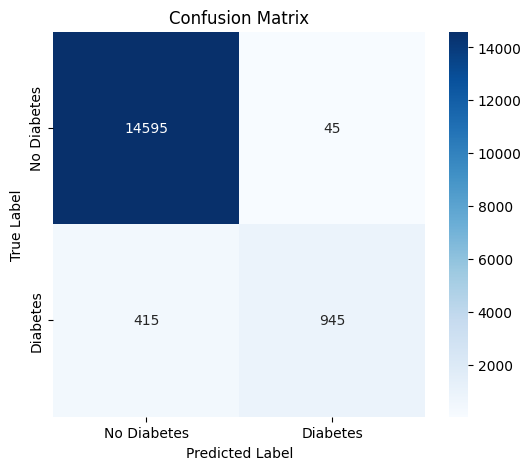

In [34]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [35]:
vd = pd.read_csv('../data/processed/validation_data.csv')
vd

,gender_female,gender_male,gender_other,smoking_history_no info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,scaler__age,scaler__hypertension,scaler__heart_disease,scaler__bmi,scaler__hba1c_level,scaler__blood_glucose_level,diabetes
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.261399,-0.284439,-0.202578,-0.705280,0.441307,0.539009,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.483456,-0.284439,-0.202578,-0.000116,0.254508,-0.296209,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.449184,-0.284439,-0.202578,-0.620901,-1.426688,-0.934905,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.572279,-0.284439,-0.202578,0.489582,-0.492690,0.539009,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.848886,-0.284439,-0.202578,-0.066413,0.254508,-1.180558,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.883159,-0.284439,-0.202578,-1.057862,-1.426688,-1.426210,0.0
19996,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.172576,-0.284439,-0.202578,-0.560631,-1.893686,-0.197948,0.0
19997,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.172576,-0.284439,-0.202578,-0.113123,0.628107,0.514444,0.0
19998,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.603881,-0.284439,-0.202578,-0.000116,0.254508,-1.303384,0.0


In [36]:
# Separate validation features and target.
X_val = vd.drop(columns=['diabetes'])
y_val = vd['diabetes']

In [37]:
# Make predictions on validation data.
y_val_pred = model.predict(X_val)

In [49]:
print("Validation Accuracy:")
print(accuracy_score(y_val, y_val_pred))

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation Accuracy:
0.97065

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     18300
         1.0       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000


Validation Confusion Matrix:
[[18235    65]
 [  522  1178]]
